# Global Superstore Profit-Leak Analysis

**Business Question:** Which product categories and markets are dragging down profitability despite high revenue — and what should leadership cut, fix, or double down on?

**Dataset:** Global Superstore (2011–2014) | 51,290 orders across 7 global markets  
**Tools:** Python (Pandas, Matplotlib, Seaborn) → Excel Dashboard  
**Author:** Somto Ogene


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


## 1. Load & Initial Inspection

In [2]:
df = pd.read_csv("Global_Superstore2.csv", encoding="latin1")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")
df.head(3)


Shape: (51290, 24)
Date range: 01-01-2011 to 31-12-2014


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium


## 2. Data Cleaning

- `Postal Code`: ~80% missing, not needed — dropped
- `Order Date` / `Ship Date`: parsed from string to datetime
- Derived columns: `Year`, `Month`, `Margin %`


In [3]:
df.drop(columns=["Postal Code"], inplace=True)
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)
df["Year"]       = df["Order Date"].dt.year
df["Month"]      = df["Order Date"].dt.to_period("M")
df["Margin %"]   = (df["Profit"] / df["Sales"]) * 100
print("Cleaning complete.")
print("Remaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Cleaning complete.
Remaining nulls:
Series([], dtype: int64)


## 3. Portfolio-Level KPIs

In [4]:
total_sales    = df["Sales"].sum()
total_profit   = df["Profit"].sum()
overall_margin = total_profit / total_sales * 100
total_orders   = df["Order ID"].nunique()
loss_orders    = df[df["Profit"] < 0].shape[0]
loss_pct       = loss_orders / len(df) * 100
total_loss     = df[df["Profit"] < 0]["Profit"].sum()
print(f"Total Revenue  : ${total_sales:>15,.0f}")
print(f"Total Profit   : ${total_profit:>15,.0f}")
print(f"Overall Margin : {overall_margin:>14.2f}%")
print(f"Unique Orders  : {total_orders:>15,}")
print(f"Loss-making rows: {loss_orders:>14,} ({loss_pct:.1f}% of all rows)")
print(f"Total losses   : ${total_loss:>15,.0f}")


Total Revenue  : $     12,642,502
Total Profit   : $      1,467,457
Overall Margin :          11.61%
Unique Orders  :          25,035
Loss-making rows:         12,544 (24.5% of all rows)
Total losses   : $       -920,646


## 4. Revenue vs Profit by Category

Furniture generates high revenue but the lowest margin (6.9%). Technology leads in absolute profit with a healthy 14% margin.

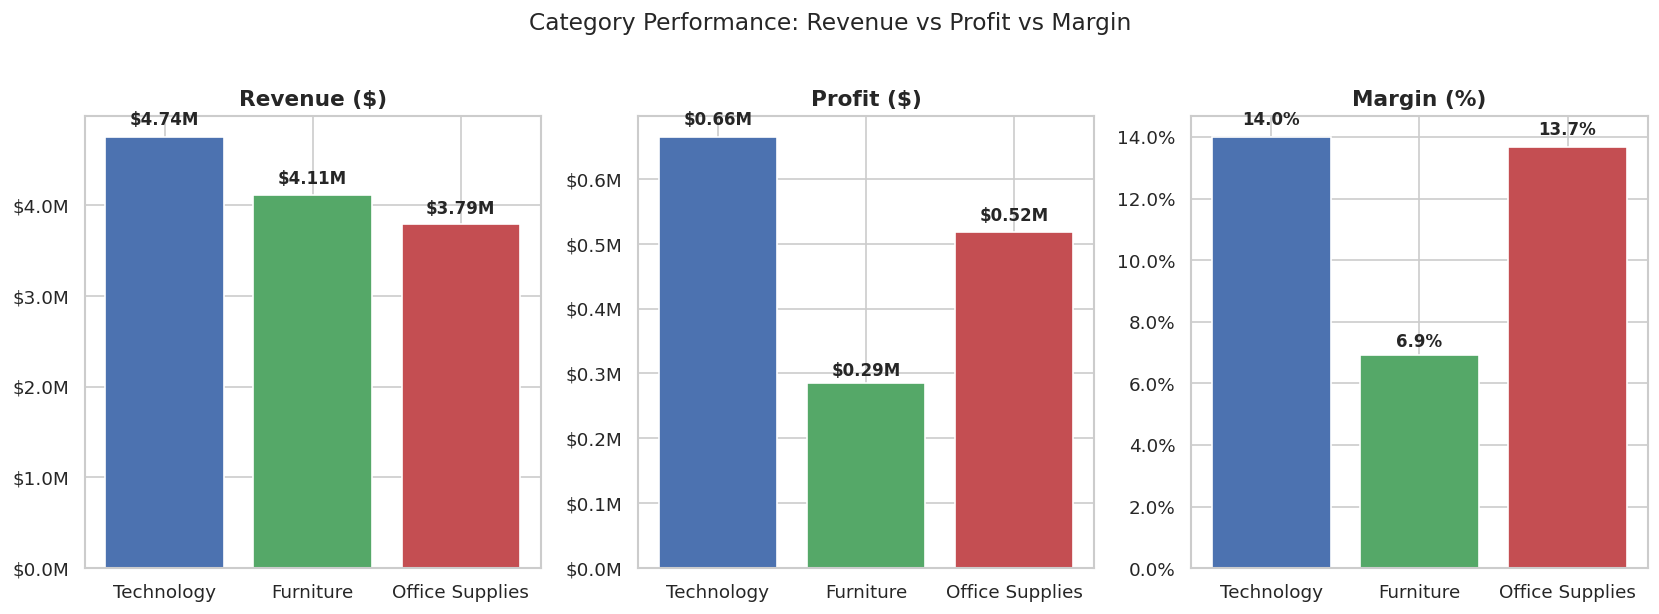

In [5]:
cat = (
    df.groupby("Category")
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
      .assign(Margin=lambda x: x["Profit"]/x["Sales"]*100)
      .sort_values("Sales", ascending=False)
      .reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]
for i, (col, label) in enumerate([("Sales","Revenue ($)"),("Profit","Profit ($)"),("Margin","Margin (%)")]):
    ax = axes[i]
    bars = ax.bar(cat["Category"], cat[col], color=colors)
    ax.set_title(label, fontsize=13, fontweight="bold")
    if col != "Margin":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    for bar, val in zip(bars, cat[col]):
        fmt = f"${val/1e6:.2f}M" if col != "Margin" else f"{val:.1f}%"
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                fmt, ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.suptitle("Category Performance: Revenue vs Profit vs Margin", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("chart_category_performance.png", bbox_inches="tight")
plt.show()


## 5. Sub-Category Profit Deep-Dive

**Tables** is the only sub-category with negative total profit (−$64K) on $757K revenue. This is the clearest profit leak — driven by aggressive discounting (~30% avg).

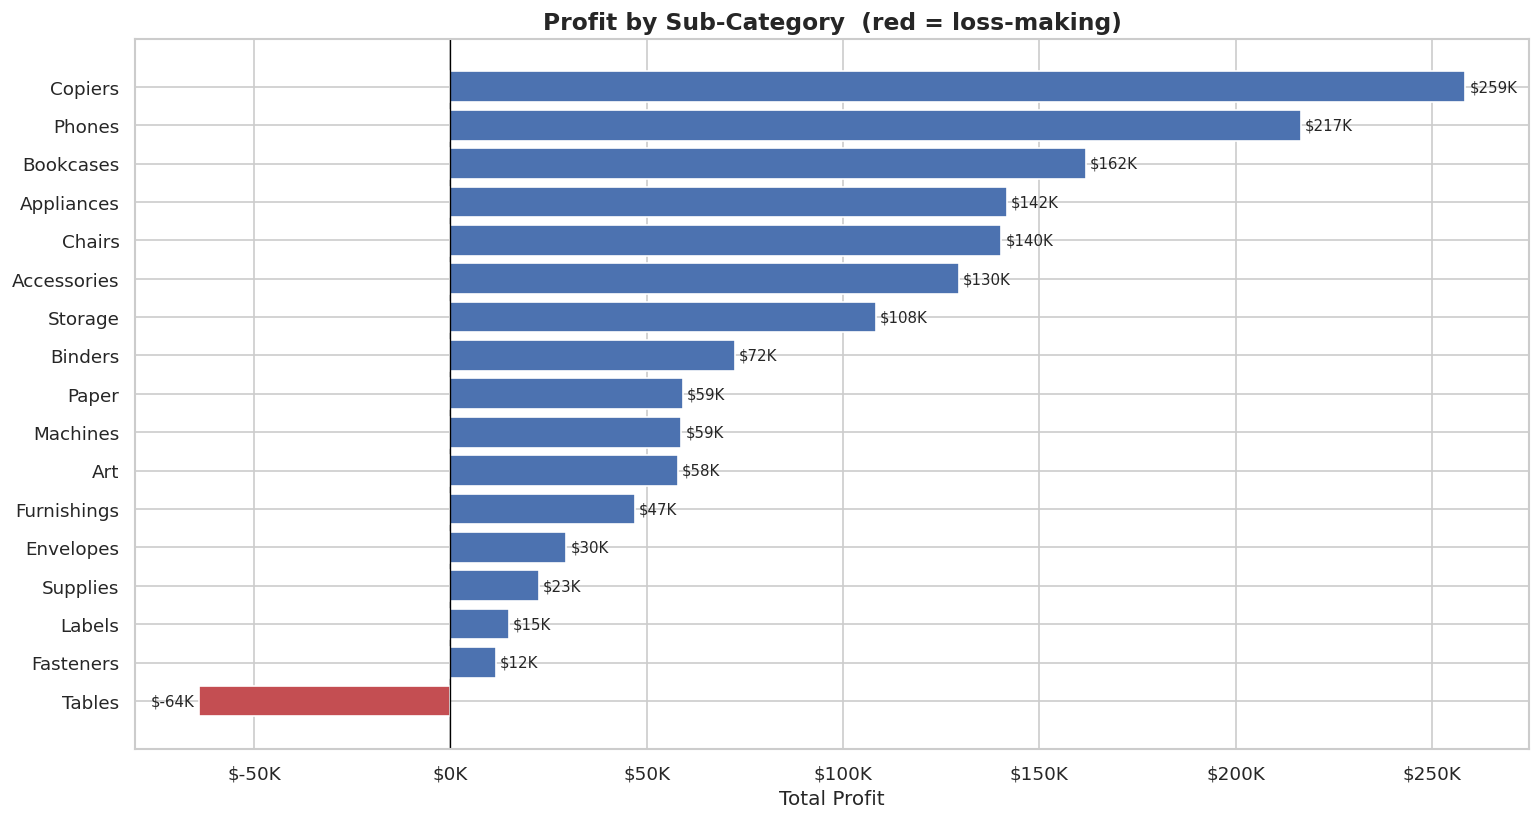

In [6]:
sub = (
    df.groupby(["Category","Sub-Category"])
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
      .assign(Margin=lambda x: x["Profit"]/x["Sales"]*100)
      .sort_values("Profit")
      .reset_index()
)
bar_colors = ["#C44E52" if p < 0 else "#4C72B0" for p in sub["Profit"]]
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(sub["Sub-Category"], sub["Profit"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.set_xlabel("Total Profit", fontsize=12)
ax.set_title("Profit by Sub-Category  (red = loss-making)", fontsize=14, fontweight="bold")
for bar, val in zip(bars, sub["Profit"]):
    xpos = val + 1000 if val >= 0 else val - 1000
    ha   = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y()+bar.get_height()/2,
            f"${val/1e3:.0f}K", va="center", ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig("chart_subcategory_profit.png", bbox_inches="tight")
plt.show()


## 6. Discount vs Profit Margin

Discount has a **−0.32 correlation with profit**. Orders with discounts >30% are almost universally loss-making.

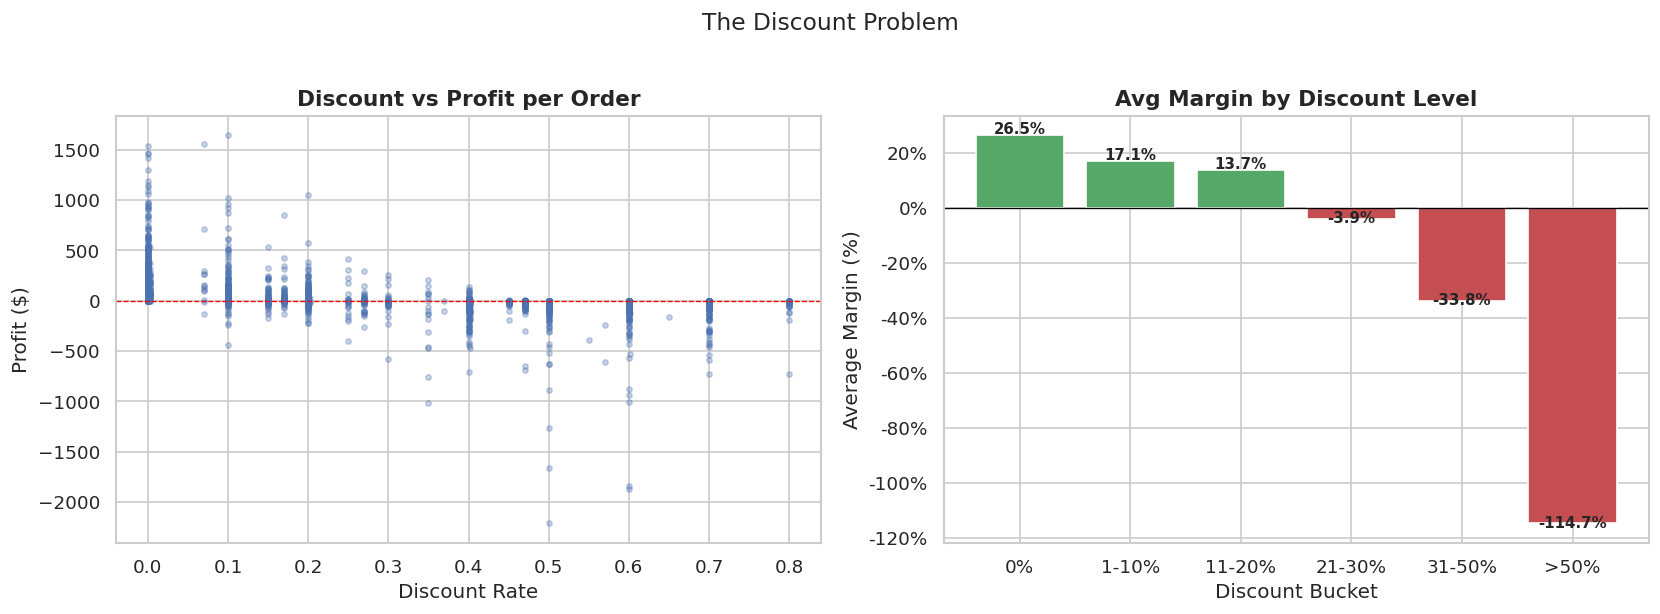

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(5000, random_state=42)
axes[0].scatter(sample["Discount"], sample["Profit"], alpha=0.3, s=10, color="#4C72B0")
axes[0].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Discount Rate")
axes[0].set_ylabel("Profit ($)")
axes[0].set_title("Discount vs Profit per Order", fontsize=13, fontweight="bold")
df["Discount Bucket"] = pd.cut(df["Discount"],
    bins=[-0.01,0,0.1,0.2,0.3,0.5,1.0],
    labels=["0%","1-10%","11-20%","21-30%","31-50%",">50%"])
disc_margin = df.groupby("Discount Bucket")["Margin %"].mean()
bar_colors2 = ["#55A868" if v >= 0 else "#C44E52" for v in disc_margin]
axes[1].bar(disc_margin.index, disc_margin.values, color=bar_colors2)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].set_xlabel("Discount Bucket")
axes[1].set_ylabel("Average Margin (%)")
axes[1].set_title("Avg Margin by Discount Level", fontsize=13, fontweight="bold")
for bar, val in zip(axes[1].patches, disc_margin.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+(0.5 if val >= 0 else -1.5),
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
plt.suptitle("The Discount Problem", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("chart_discount_impact.png", bbox_inches="tight")
plt.show()


## 7. Market-Level Profitability

APAC and EU are the highest-profit markets. EMEA has the weakest margin (5.4%) — revenue potential undermined by high costs and discounting.

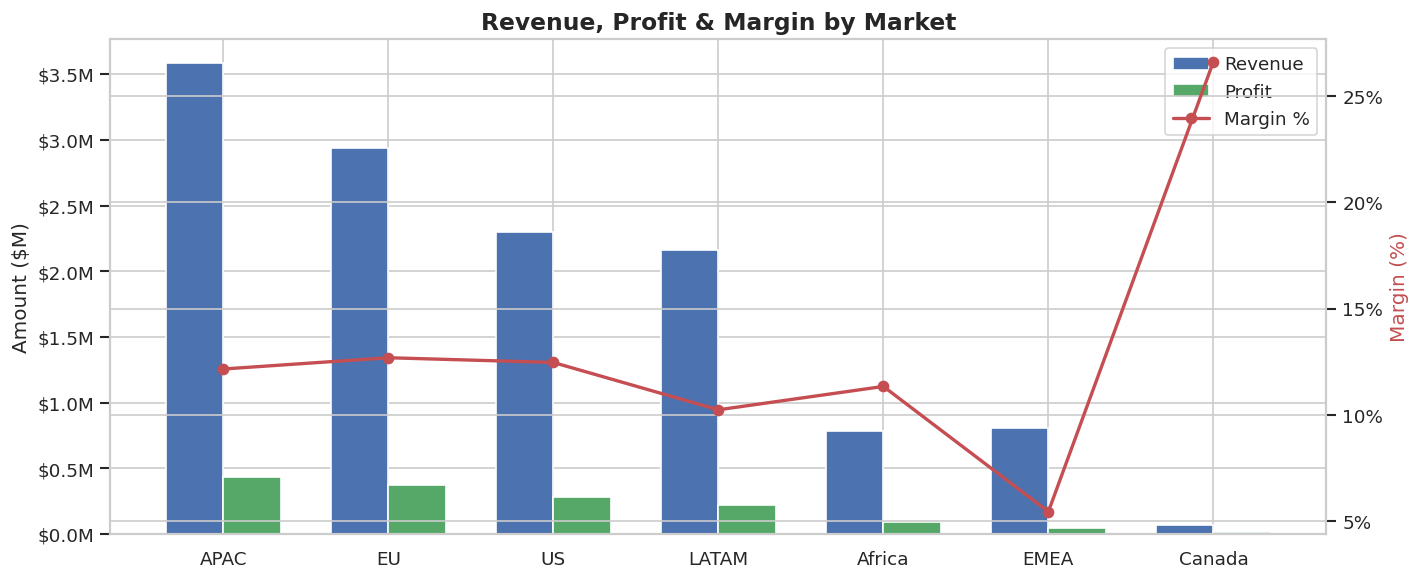

In [8]:
mkt = (
    df.groupby("Market")
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
      .assign(Margin=lambda x: x["Profit"]/x["Sales"]*100)
      .sort_values("Profit", ascending=False)
      .reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(mkt))
width = 0.35
ax.bar([i-width/2 for i in x], mkt["Sales"]/1e6,  width, label="Revenue", color="#4C72B0")
ax.bar([i+width/2 for i in x], mkt["Profit"]/1e6, width, label="Profit",  color="#55A868")
ax2 = ax.twinx()
ax2.plot(list(x), mkt["Margin"], color="#C44E52", marker="o", linewidth=2, label="Margin %")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.set_ylabel("Margin (%)", color="#C44E52")
ax.set_xticks(list(x))
ax.set_xticklabels(mkt["Market"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax.set_ylabel("Amount ($M)")
ax.set_title("Revenue, Profit & Margin by Market", fontsize=14, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc="upper right")
plt.tight_layout()
plt.savefig("chart_market_profitability.png", bbox_inches="tight")
plt.show()


## 8. Year-over-Year Trend (2011–2014)

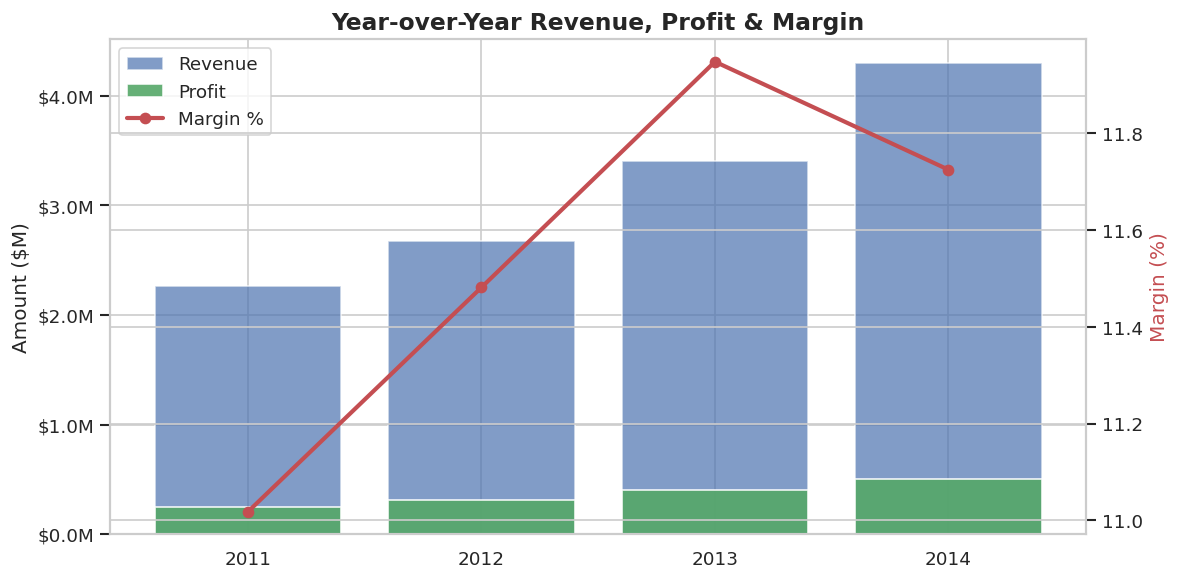

In [9]:
yearly = (
    df.groupby("Year")
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
      .assign(Margin=lambda x: x["Profit"]/x["Sales"]*100)
      .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly["Year"].astype(str), yearly["Sales"]/1e6,  color="#4C72B0", label="Revenue", alpha=0.7)
ax.bar(yearly["Year"].astype(str), yearly["Profit"]/1e6, color="#55A868", label="Profit",  alpha=0.9)
ax2 = ax.twinx()
ax2.plot(yearly["Year"].astype(str), yearly["Margin"], color="#C44E52", marker="o", linewidth=2.5, label="Margin %")
ax2.set_ylabel("Margin (%)", color="#C44E52")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax.set_ylabel("Amount ($M)")
ax.set_title("Year-over-Year Revenue, Profit & Margin", fontsize=14, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2)
plt.tight_layout()
plt.savefig("chart_yearly_trend.png", bbox_inches="tight")
plt.show()


## 9. Key Findings & Recommendations

### Findings

1. **Tables is a money-loser.** $757K revenue, −$64K profit. Every table sold costs money. Root cause: ~30% average discount on this sub-category.

2. **Discounts above 20% destroy margin.** Orders with >30% discount average −15% margin. The −0.32 discount-profit correlation is not noise.

3. **Furniture drags the portfolio.** 6.9% margin vs 14% for Technology. Tables and Bookcases are the worst offenders within the category.

4. **EMEA underperforms.** Lowest margin at 5.4% — likely high shipping costs combined with aggressive regional discounting.

5. **APAC and EU are the growth engines.** Together they account for $808K of $1.47M total profit.

6. **24.5% of all order rows are loss-making** — totalling −$920K that partially cancels gross profit.

### Recommendations

- **Cut or reprice Tables**: Raise prices, eliminate discounts, or exit the sub-category.
- **Implement a 20% discount ceiling** — especially for Furniture. A one-quarter controlled test would validate the margin recovery.
- **Prioritize APAC and EU** for sales and marketing investment.
- **Audit EMEA operations** before further revenue expansion there.
